In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv('C:/PROJECTS/Covid19-analysis/Data/owid-covid-data.csv')
df.head(5)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [8]:
df.shape

(44785, 41)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  str    
 1   continent                        44257 non-null  str    
 2   location                         44785 non-null  str    
 3   date                             44785 non-null  str    
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_million            43918 non-null  float64
 12  new_cases_smoothed_per_millio

In [10]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
count,4.418200e+04,43982.000000,43200.000000,44182.000000,43982.000000,43200.000000,43918.000000,43918.000000,43135.000000,43918.000000,...,39442.000000,26322.000000,39967.000000,41366.000000,31358.000000,30963.000000,18658.000000,36139.000000,43963.000000,38558.000000
mean,9.372153e+04,1388.770224,1372.258368,3885.163189,43.323360,43.329499,1778.176471,23.573850,23.160618,55.320410,...,20979.943732,12.029018,251.347231,8.048869,10.834007,32.637049,52.576272,3.115428,74.052595,0.725580
std,9.707004e+05,12665.458657,12420.794948,36227.966483,366.554434,356.193423,3814.416468,72.289186,55.613758,140.662359,...,20466.166309,19.158253,117.620708,4.143192,10.481952,13.408593,31.579386,2.530433,7.364382,0.152673
min,0.000000e+00,-8261.000000,-552.000000,0.000000,-1918.000000,-232.143000,0.000000,-2212.545000,-269.978000,0.000000,...,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.188000,0.100000,53.280000,0.354000
25%,5.300000e+01,0.000000,0.571000,0.000000,0.000000,0.000000,25.373750,0.000000,0.123000,0.000000,...,5338.454000,0.500000,155.898000,5.310000,1.900000,21.400000,21.222000,1.300000,69.910000,0.606000
50%,9.370000e+02,9.000000,14.143000,17.000000,0.000000,0.143000,266.509000,1.475500,2.838000,4.566000,...,14103.452000,1.800000,238.339000,7.110000,6.400000,31.400000,55.182000,2.500000,75.490000,0.755000
75%,9.989000e+03,156.000000,160.857000,213.000000,3.000000,3.000000,1793.012500,16.551500,18.200500,33.616750,...,32415.132000,16.000000,318.949000,10.180000,19.600000,40.900000,83.741000,4.200000,79.930000,0.853000
max,3.054045e+07,313658.000000,288630.000000,952724.000000,10491.000000,7456.714000,42663.811000,4944.376000,882.924000,1237.551000,...,116935.600000,77.600000,724.417000,23.360000,44.000000,78.100000,98.999000,13.800000,86.750000,0.953000


DATA PREPROCESSING

In [11]:
print(df.isnull().sum()) # Count of missing values in each column


iso_code                             264
continent                            528
location                               0
date                                   0
total_cases                          603
new_cases                            803
new_cases_smoothed                  1585
total_deaths                         603
new_deaths                           803
new_deaths_smoothed                 1585
total_cases_per_million              867
new_cases_per_million                867
new_cases_smoothed_per_million      1650
total_deaths_per_million             867
new_deaths_per_million               867
new_deaths_smoothed_per_million     1650
new_tests                          29138
total_tests                        28763
total_tests_per_thousand           28763
new_tests_per_thousand             29138
new_tests_smoothed                 27217
new_tests_smoothed_per_thousand    27217
tests_per_case                     28636
positive_rate                      28252
tests_units     

In [12]:
print(df.isnull().sum()/len(df)*100)# Percentage of missing values in each column

iso_code                            0.589483
continent                           1.178966
location                            0.000000
date                                0.000000
total_cases                         1.346433
new_cases                           1.793011
new_cases_smoothed                  3.539131
total_deaths                        1.346433
new_deaths                          1.793011
new_deaths_smoothed                 3.539131
total_cases_per_million             1.935916
new_cases_per_million               1.935916
new_cases_smoothed_per_million      3.684269
total_deaths_per_million            1.935916
new_deaths_per_million              1.935916
new_deaths_smoothed_per_million     3.684269
new_tests                          65.061963
total_tests                        64.224629
total_tests_per_thousand           64.224629
new_tests_per_thousand             65.061963
new_tests_smoothed                 60.772580
new_tests_smoothed_per_thousand    60.772580
tests_per_

In [13]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'tests_per_case', 'positive_rate', 'tests_units', 'stringency_index',
       'population', 'population_density', 'median_age', 'aged_65_older',
       'aged_70_older', 'gdp_per_capita', 'extreme_poverty',
       'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers',
       'male_smokers', 'handwashing_facilities', 'hospital_beds_per_thousand',
       'life_expectancy', 'human_development_index'],
      dtype='str')

In [14]:
columns_needed=[
    "location",
    "date",
    "total_cases",
    "new_cases",
    "total_deaths",
    "new_deaths",
    "population"
]
df = df[columns_needed]


In [15]:
#convert date column to datetime format
df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   location      44785 non-null  str           
 1   date          44785 non-null  datetime64[us]
 2   total_cases   44182 non-null  float64       
 3   new_cases     43982 non-null  float64       
 4   total_deaths  44182 non-null  float64       
 5   new_deaths    43982 non-null  float64       
 6   population    44521 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 2.4 MB


In [16]:
# Handling missing numeric values by filling with 0
numeric_columns=['total_cases', 'new_cases', 'total_deaths', 'new_deaths']
df[numeric_columns] = df[numeric_columns].fillna(0)
# Handling missing categorical values by filling with 'Unknown'
df['location'] = df['location'].fillna('Unknown')


TREND ANALYSIS  OF NEPAL

In [17]:
#choosing and making  a copy of data for a specific country
country = "Nepal"
df_country =df[df['location']==country].copy()
df_country.head(5)

,location,date,total_cases,new_cases,total_deaths,new_deaths,population
28392,Nepal,2019-12-31,0.0,0.0,0.0,0.0,29136808.0
28393,Nepal,2020-01-01,0.0,0.0,0.0,0.0,29136808.0
28394,Nepal,2020-01-02,0.0,0.0,0.0,0.0,29136808.0
28395,Nepal,2020-01-03,0.0,0.0,0.0,0.0,29136808.0
28396,Nepal,2020-01-04,0.0,0.0,0.0,0.0,29136808.0


C:\Users\DIPESH\AppData\Local\Temp\ipykernel_10464\1052751166.py:4: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.dates.AutoDateLocator'>
  plt.locator_params(axis='x', nbins=10) # Limit the number of x-axis ticks


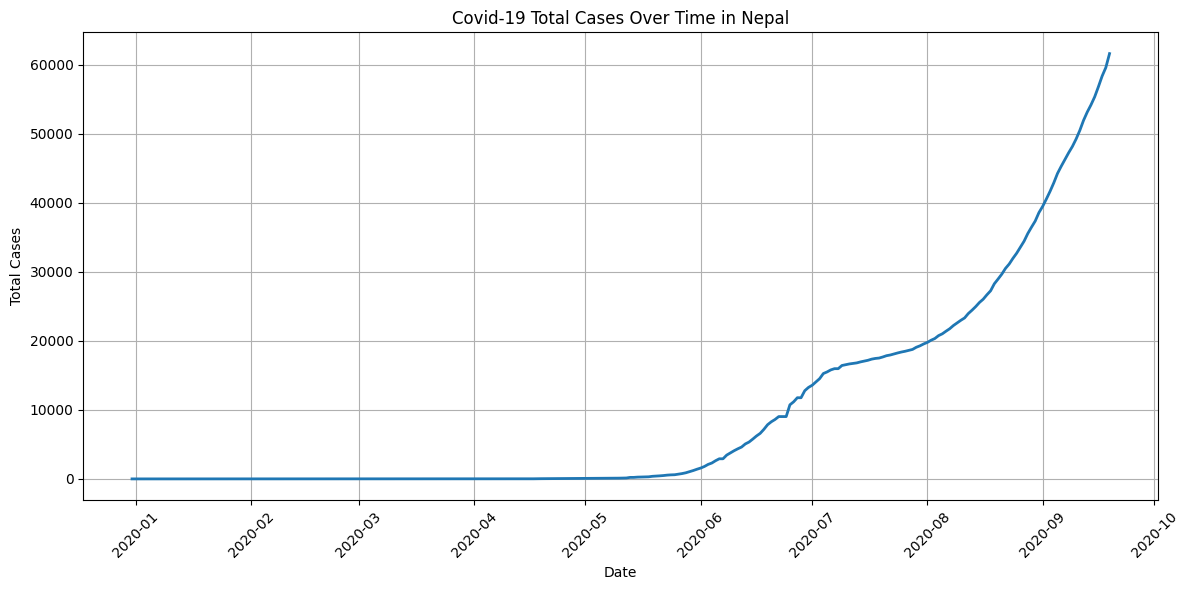

In [18]:
#plotting the total cases over time
plt.figure(figsize=(12,6))
plt.plot(df_country['date'], df_country['total_cases'],linewidth=2)
plt.locator_params(axis='x', nbins=10) # Limit the number of x-axis ticks
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.title(f'Covid-19 Total Cases Over Time in {country}')
plt.xticks(rotation=45)# Rotate x-axis labels for better readability
plt.tight_layout()# Adjust layout to prevent clipping of labels
plt.grid()
plt.show()


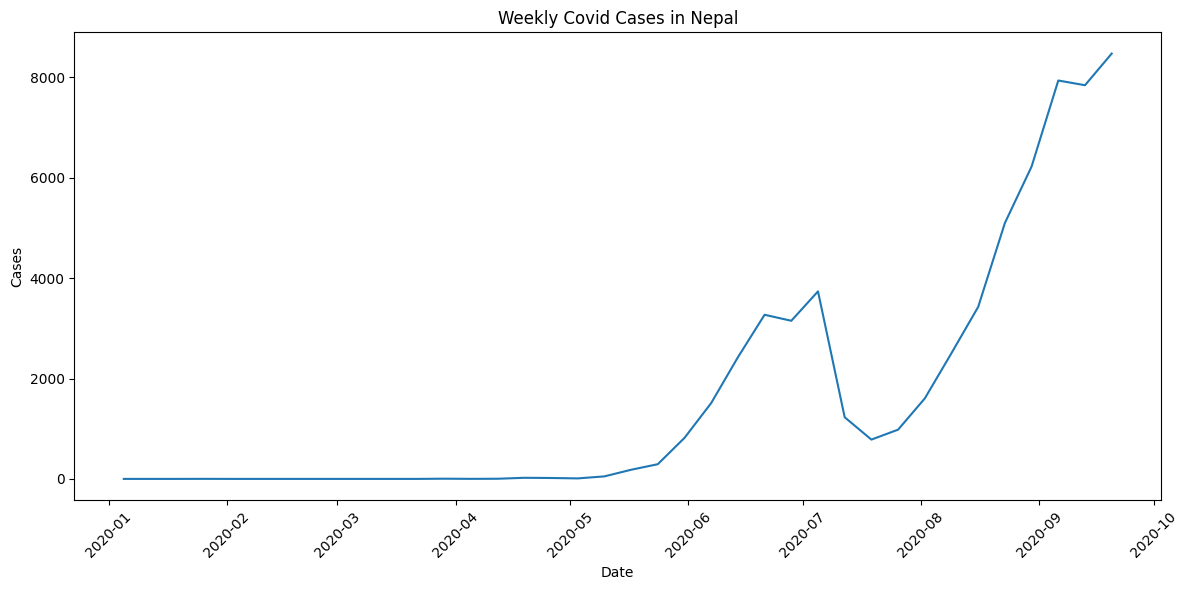

In [19]:
# Reload dataset
df = pd.read_csv('C:/PROJECTS/Covid19-analysis/Data/owid-covid-data.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Set index
df = df.set_index("date")

# Filter Nepal
nepal_df = df[df["location"] == "Nepal"]
weekly_cases = nepal_df["new_cases"].resample("W").sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(weekly_cases)

plt.title("Weekly Covid Cases in Nepal")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



COVID 19 WAVE COMPARISIONS BETWEEN NEPAL, INDIA AND CHINA

In [20]:
countries = ['Nepal', 'India', 'China']
from scipy.signal import find_peaks
data=pd.read_csv('C:/PROJECTS/Covid19-analysis/Data/owid-covid-data.csv')
data['date'] = pd.to_datetime(data['date'])
#function to  prepare data for a country
def prepare_country_data(country, height_threshold=50): # Adjust this threshold based on the scale of cases in the country
    country_data=data[data['location'] == country][['date', 'new_cases']].copy()# Select only date and new_cases columns
    country_data['new_cases'] = country_data['new_cases'].fillna(0)# Fill missing values with 0
    country_data['rolling_avg'] = country_data['new_cases'].rolling(window=7).mean()# Calculate 7-day rolling average to smooth the data

    #find peaks
    cases=rolling_avg = country_data['rolling_avg'].to_numpy() # Convert to numpy array for find_peaks
    peaks, _ = find_peaks(cases, height=height_threshold) # Find peaks
    peak_dates = country_data['date'].iloc[peaks] # Get corresponding dates for peaks
    peak_values = country_data['rolling_avg'].iloc[peaks] # Get corresponding new_cases values for peaks
    
    return country_data, peak_dates, peak_values



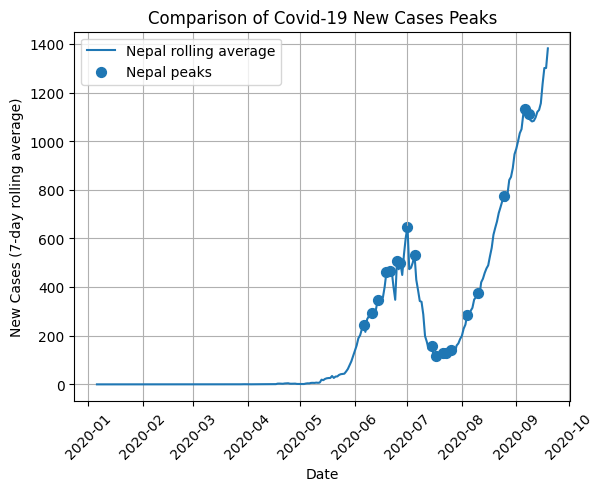

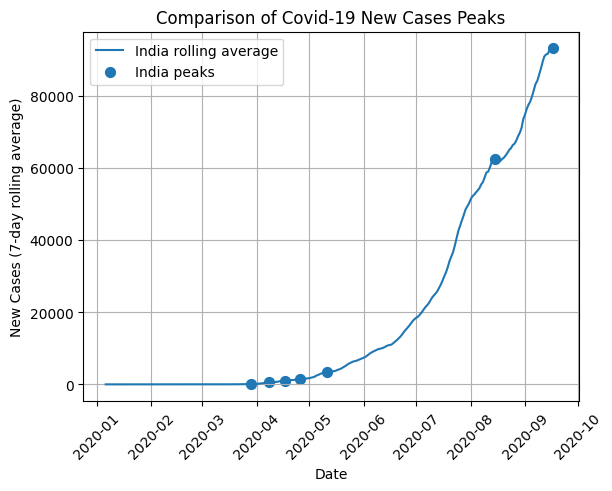

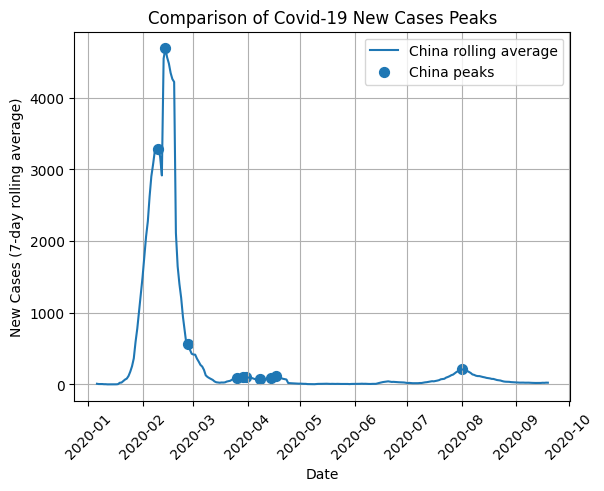

In [21]:
#plot comparisions
plt.Figure(figsize=(12,6))
for country in countries:
    country_data, peak_dates, peak_values = prepare_country_data(country, height_threshold=50)# Adjust this threshold based on the scale of cases in the country

    #plotting the rolling average of new cases
    plt.plot(country_data['date'], country_data['rolling_avg'], label=f'{country} rolling average')# Plot rolling average of new cases
    
    #plotting peaks
    plt.scatter(peak_dates, peak_values,marker='o',s=50, label=f'{country} peaks')# Plot peaks of new cases
    plt.title('Comparison of Covid-19 New Cases Peaks')
    plt.xlabel('Date')
    plt.ylabel('New Cases (7-day rolling average)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.show()

In [22]:
# COMPARE PEAKS IN TABLES
peak_summary = []

for country in countries:
    _, peak_dates, peak_values = prepare_country_data(country, height_threshold=4)
    for date, value in zip(peak_dates, peak_values):
        peak_summary.append({'Country': country, 'Date': date.date(), 'Peak Cases': int(value)})

peak_df = pd.DataFrame(peak_summary)
print(peak_df.sort_values(['Country', 'Date']))


   Country        Date  Peak Cases
32   China  2020-02-10        3285
33   China  2020-02-14        4687
34   China  2020-02-27         563
35   China  2020-03-17          26
36   China  2020-03-26          86
..     ...         ...         ...
20   Nepal  2020-08-04         285
21   Nepal  2020-08-10         377
22   Nepal  2020-08-25         776
23   Nepal  2020-09-06        1133
24   Nepal  2020-09-08        1110

[64 rows x 3 columns]


DEATH RATE ANALYSIS

In [23]:
def death_rate_analysis(country):
    df=data[data['location']==country].copy() # Filter data for the specified country and create a copy to avoid SettingWithCopyWarning
    df['new_deaths']=df['new_deaths'].fillna(0) # Fill missing values in new_deaths with 0
    df['total_deaths']=df['total_deaths'].fillna(0) # Fill missing values in total_deaths with 0    
    df['total_cases']=df['total_cases'].fillna(0) # Fill missing values in total_cases with 0
    df['death_avg']=df['new_deaths'].rolling(window=7).mean() # Calculate 7-day rolling average of new deaths
    df['death_rate']=df['death_avg']/df['total_cases']*100 # Calculate death rate as percentage of total cases
    return df[['date', 'death_rate']]   


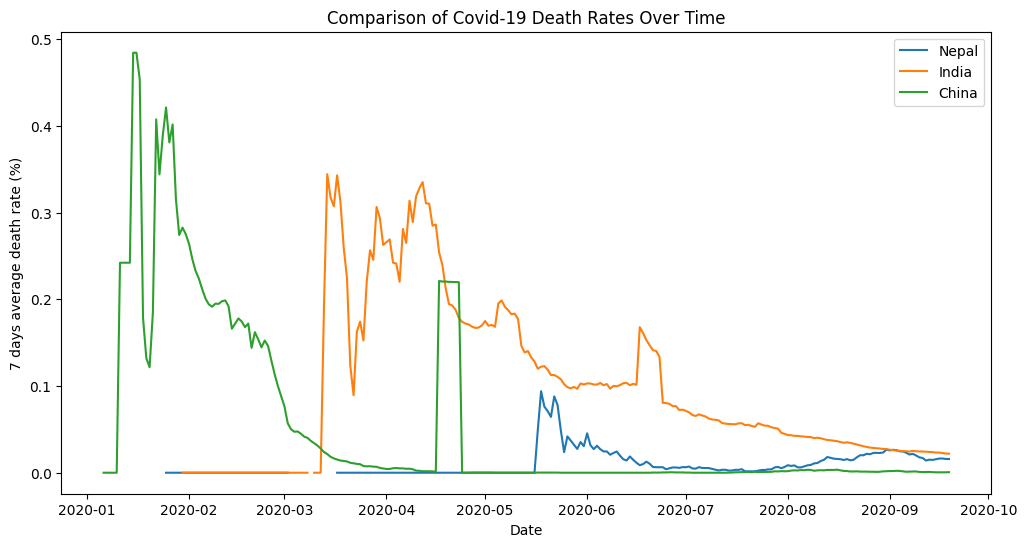

In [24]:
#ploitting death rate over time
plt.figure(figsize=(12,6))
for country in countries:# Loop through each country in the list
    df = death_rate_analysis(country) # Get death rate data for the country
    plt.plot(df['date'], df['death_rate'], label=country) # Plot death rate over time for the country
plt.title('Comparison of Covid-19 Death Rates Over Time')
plt.xlabel('Date')
plt.ylabel('7 days average death rate (%)')
plt.legend()

DEATH RATE COMPARISION OF NEPAL OVER 5 YEARS

In [25]:
#filtering data for Nepal
df=data[data['location']=='Nepal'].copy() 
df.head(5)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
28392,NPL,Asia,Nepal,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,2442.804,15.0,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574
28393,NPL,Asia,Nepal,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,2442.804,15.0,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574
28394,NPL,Asia,Nepal,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,2442.804,15.0,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574
28395,NPL,Asia,Nepal,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,2442.804,15.0,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574
28396,NPL,Asia,Nepal,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,2442.804,15.0,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574


In [26]:
#extract year
df['year']=df['date'].dt.year# this will extract the year from the date column and create a new column called 'year' in the dataframe.

#filling missing values in new_cases with 0
df['new_cases']=df['new_cases'].fillna(0)
#filling missing values in new_deaths with 0
df['new_deaths']=df['new_deaths'].fillna(0)


In [27]:
#grouping data by year and calculating total cases and deaths
yearly_summary = df.groupby('year').agg({
    'new_cases': 'sum',
    'new_deaths': 'sum'}).reset_index() # This will group the data by the 'year' column and calculate the sum of 'new_cases' and 'new_deaths' for each year, resulting in a new dataframe called 'yearly_summary'.


In [28]:
#caluculating death rate for each year
yearly_summary['death_rate']=yearly_summary['new_deaths']/yearly_summary['new_cases']*100 # This will calculate the death rate for each year by dividing the total number of new deaths by the total number of new cases and multiplying by 100 to get a percentage, resulting in a new column called 'death_rate' in the 'yearly_summary' dataframe.
yearly_summary




,year,new_cases,new_deaths,death_rate
0,2019,0.0,0.0,NaN
1,2020,61593.0,390.0,0.633189


monthly COVID-19 death rate analysis for a year.

In [29]:
df = df[(df['date'].dt.year >= 2019) & (df['date'].dt.year <= 2021)]
df['year_month'] = df['date'].dt.to_period('M')  # e.g., 2020-03 creates a new column 'year_month' that contains the year and month extracted from the 'date' column in the format 'YYYY-MM'.
df


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,year,year_month
28392,NPL,Asia,Nepal,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2019,2019-12
28393,NPL,Asia,Nepal,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-01
28394,NPL,Asia,Nepal,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-01
28395,NPL,Asia,Nepal,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-01
28396,NPL,Asia,Nepal,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28651,NPL,Asia,Nepal,2020-09-15,55329.0,1170.0,1156.143,360.0,15.0,8.571,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-09
28652,NPL,Asia,Nepal,2020-09-16,56788.0,1459.0,1235.714,371.0,11.0,9.286,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-09
28653,NPL,Asia,Nepal,2020-09-17,58327.0,1539.0,1301.143,379.0,8.0,9.571,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-09
28654,NPL,Asia,Nepal,2020-09-18,59573.0,1246.0,1301.143,383.0,4.0,9.429,...,260.797,7.26,9.5,37.8,47.782,0.3,70.78,0.574,2020,2020-09


In [30]:
monthly_summary = df.groupby('year_month').agg({
    'new_cases': 'sum',
    'new_deaths': 'sum'}).reset_index() # This will group the data by the 'year_month' column and calculate the sum of 'new_cases' and 'new_deaths' for each month, resulting in a new dataframe called 'monthly_summary'.
#caluculating death rate for each month
monthly_summary['death_rate']=monthly_summary['new_deaths']/monthly_summary['new_cases']*100 # This will calculate the death rate for each month by dividing the total number of new deaths by the total number of new cases and multiplying by 100 to get a percentage, resulting in a new column called 'death_rate' in the 'monthly_summary' dataframe.
monthly_summary 

,year_month,new_cases,new_deaths,death_rate
0,2019-12,0.0,0.0,NaN
1,2020-01,1.0,0.0,0.000000
2,2020-02,0.0,0.0,NaN
3,2020-03,4.0,0.0,0.000000
4,2020-04,52.0,0.0,0.000000
5,2020-05,1344.0,6.0,0.446429
6,2020-06,11847.0,23.0,0.194142
7,2020-07,6299.0,23.0,0.365137
8,2020-08,19014.0,169.0,0.888819
9,2020-09,23032.0,169.0,0.733762


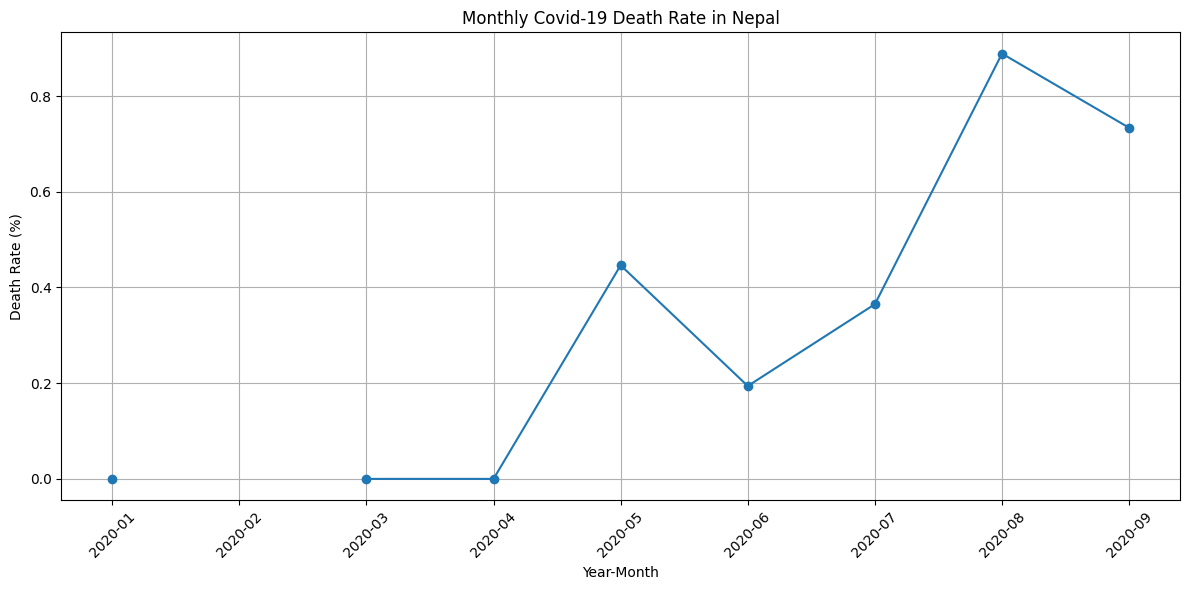

In [31]:
#plotting monthly death rate over time
plt.figure(figsize=(12,6))
plt.plot(monthly_summary['year_month'].astype(str), monthly_summary['death_rate'], marker='o') # Plotting the death rate over time with markers for each month  astype(str) is used to convert the 'year_month' column to string format for better x-axis labeling .
plt.title('Monthly Covid-19 Death Rate in Nepal')
plt.xlabel('Year-Month')
plt.ylabel('Death Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()# Adjust layout to prevent clipping of labels
plt.grid()
plt.show()

TOP COUNTRIES ANALYSIS

In [32]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'tests_per_case', 'positive_rate', 'tests_units', 'stringency_index',
       'population', 'population_density', 'median_age', 'aged_65_older',
       'aged_70_older', 'gdp_per_capita', 'extreme_poverty',
       'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers',
       'male_smokers', 'handwashing_facilities', 'hospital_beds_per_thousand',
       'life_expectancy', 'human_development_index', 'year', 'year_month'],
      dtype='str')

In [33]:
df=pd.read_csv('C:/PROJECTS/Covid19-analysis/Data/owid-covid-data.csv')#reloading the dataset to get the original data for country summary
df = df[df["continent"].notna()]# This will filter the dataframe to include only rows where the 'continent' column is not null, effectively removing any entries that do not have a specified continent.there was a world map entry with no continent which was causing issues in grouping by country.
country_summary=df.groupby('location')[['new_cases', 'new_deaths']].max().reset_index() # This will group the data by the 'country' column and calculate the sum of 'new_cases' and 'new_deaths' for each country, resulting in a new dataframe called 'country_summary'.
country_summary


,location,new_cases,new_deaths
0,Afghanistan,1063.0,56.0
1,Albania,178.0,6.0
2,Algeria,675.0,42.0
3,Andorra,94.0,4.0
4,Angola,180.0,6.0
...,...,...,...
205,Vietnam,50.0,4.0
206,Western Sahara,242.0,1.0
207,Yemen,116.0,52.0
208,Zambia,527.0,40.0


In [34]:
#top 10 countries with highest new cases
top_cases=country_summary.sort_values('new_cases', ascending=False).head(10) # This will sort the 'country_summary' dataframe by the 'new_cases' column in descending order and return the top 10 rows, resulting in a new dataframe called 'top_cases' that contains the countries with the highest number of new cases.
top_cases

,location,new_cases,new_deaths
90,India,97894.0,2003.0
199,United States,78427.0,4928.0
27,Brazil,69074.0,1595.0
40,Chile,36179.0,1057.0
177,Spain,27404.0,1179.0
102,Kazakhstan,19246.0,324.0
41,China,15141.0,1290.0
174,South Africa,13944.0,572.0
68,France,13215.0,2004.0
42,Colombia,13056.0,400.0


In [35]:
#top 10 countries with highest new deaths
top_deaths=country_summary.sort_values('new_deaths', ascending=False).head(10) # This will sort the 'country_summary' dataframe by the 'new_deaths' column in descending order and return the top 10 rows, resulting in a new dataframe called 'top_deaths' that contains the countries with the highest number of new deaths.
top_deaths

,location,new_cases,new_deaths
199,United States,78427.0,4928.0
150,Peru,10143.0,3935.0
57,Ecuador,11536.0,3800.0
68,France,13215.0,2004.0
90,India,97894.0,2003.0
23,Bolivia,2687.0,1610.0
27,Brazil,69074.0,1595.0
41,China,15141.0,1290.0
198,United Kingdom,5487.0,1224.0
177,Spain,27404.0,1179.0


In [36]:
#case fatality rate
country_summary["CFR"]=country_summary['new_deaths']/country_summary['new_cases']*100 # This will calculate the case fatality rate (CFR) for each country by dividing the total number of new deaths by the total number of new cases and multiplying by 100 to get a percentage, resulting in a new column called 'CFR' in the 'country_summary' dataframe.
country_summary

,location,new_cases,new_deaths,CFR
0,Afghanistan,1063.0,56.0,5.268109
1,Albania,178.0,6.0,3.370787
2,Algeria,675.0,42.0,6.222222
3,Andorra,94.0,4.0,4.255319
4,Angola,180.0,6.0,3.333333
...,...,...,...,...
205,Vietnam,50.0,4.0,8.000000
206,Western Sahara,242.0,1.0,0.413223
207,Yemen,116.0,52.0,44.827586
208,Zambia,527.0,40.0,7.590133


In [42]:
#top 15 countries with highest case fatality rate
top_cfr=country_summary.sort_values('CFR', ascending=False).head(15) # This will sort the 'country_summary' dataframe by the 'CFR' column in descending order and return the top 10 rows, resulting in a new dataframe called 'top_cfr' that contains the countries with the highest case fatality rate.
top_cfr

,location,new_cases,new_deaths,CFR
23,Bolivia,2687.0,1610.0,59.918124
207,Yemen,116.0,52.0,44.827586
150,Peru,10143.0,3935.0,38.795228
111,Liberia,45.0,15.0,33.333333
57,Ecuador,11536.0,3800.0,32.940361
142,Northern Mariana Islands,4.0,1.0,25.000000
24,Bonaire Sint Eustatius and Saba,4.0,1.0,25.000000
130,Montserrat,4.0,1.0,25.000000
198,United Kingdom,5487.0,1224.0,22.307272
94,Ireland,1169.0,234.0,20.017109


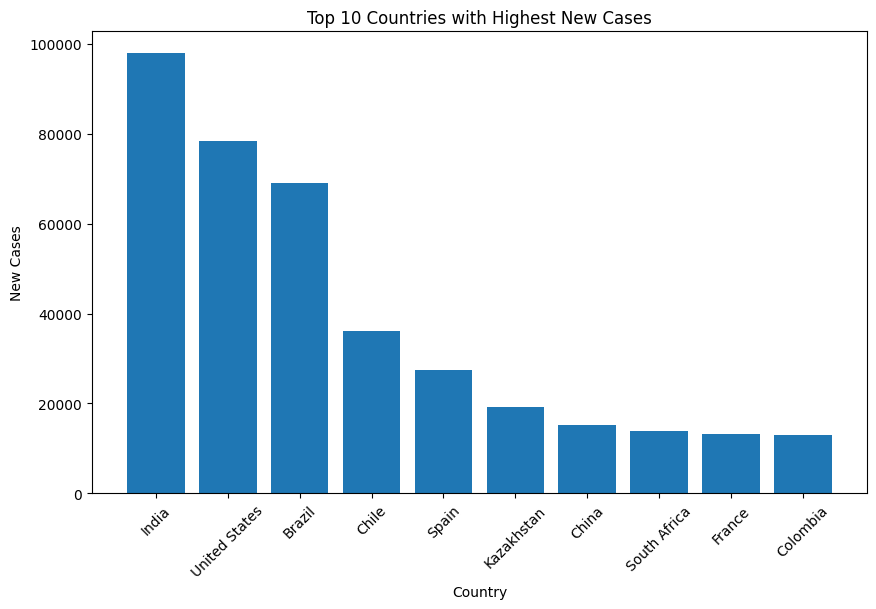

In [40]:
#visusalization of top 10 countries with highest cases
plt.figure(figsize=(10,6))
plt.bar(top_cases['location'], top_cases['new_cases'])
plt.xlabel('Country')
plt.ylabel('New Cases')
plt.title('Top 10 Countries with Highest New Cases')
plt.xticks(rotation=45)
plt.show()

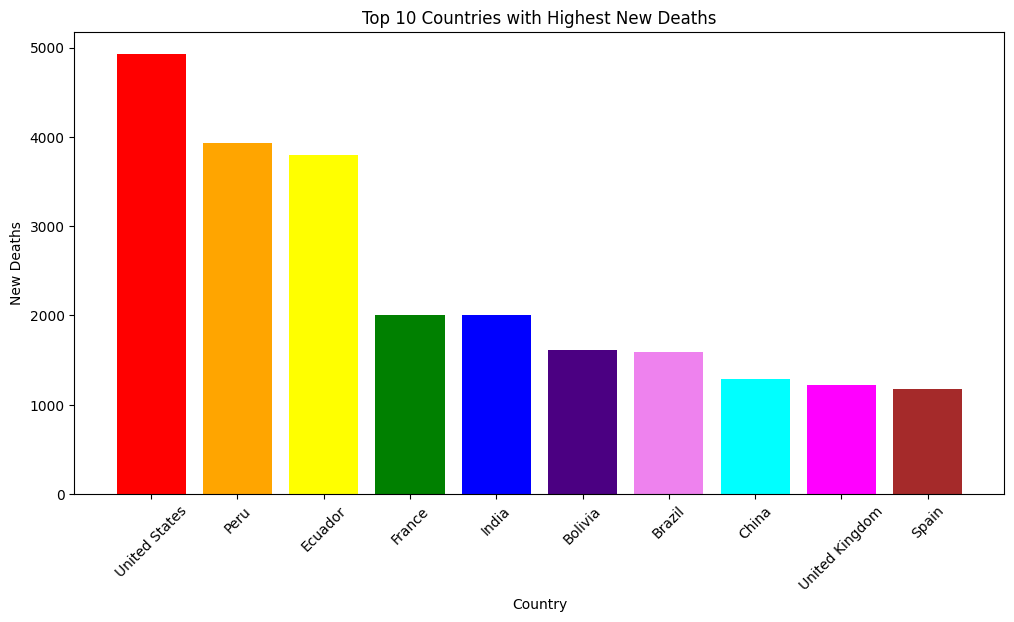

In [ ]:
#visualizing top 10 countries by new deaths
plt.figure(figsize=(12,6))
#change the bar colours for different counntries
plt.bar(top_deaths['location'], top_deaths['new_deaths'], color=['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet', 'cyan', 'magenta', 'brown'])
plt.xlabel('Country')
plt.ylabel('New Deaths')
plt.title('Top 10 Countries with Highest New Deaths')
plt.xticks(rotation=45)
plt.show()

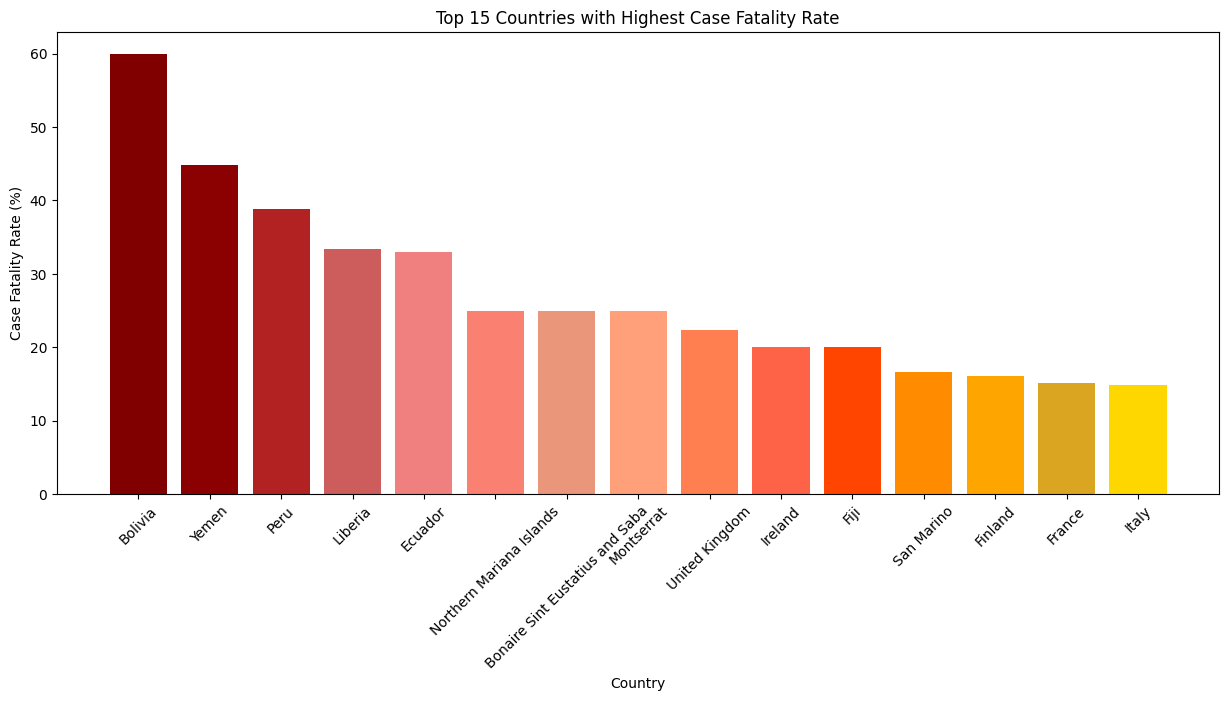

In [43]:
#visualization of top 15 countries with highest case fatality rate
plt.figure(figsize=(15,6))
plt.bar(top_cfr['location'], top_cfr['CFR'], color=['maroon', 'darkred', 'firebrick', 'indianred', 'lightcoral', 'salmon', 'darksalmon', 'lightsalmon', 'coral', 'tomato', 'orangered', 'darkorange', 'orange', 'goldenrod', 'gold'])
plt.xlabel('Country')
plt.ylabel('Case Fatality Rate (%)')
plt.title('Top 15 Countries with Highest Case Fatality Rate')
plt.xticks(rotation=45)
plt.show()
